# RELATÓRIO TÉCNICO-CIENTÍFICO DE CALIBRAÇÃO EMPÍRICA
## Engenharia de Programa 2026.2 / Prof. Diego Frias
### Paradigma F.O.C.A. — 4.2. Custo de Comparações (τc)
**Responsável: Aluno 2**

**Objetivo:** Executar a medição empírica direta in-line, filtragem de outliers por percentil (5% e 95%) e homologação dos custos de tempo (τc) para primitivas de comparação, garantindo a estabilidade (CV < 0.15).

**Painel Gráfico de Estabilidade (Seção 3):** Exatamente 3 gráficos consolidados contendo todas as primitivas de comparação sobrepostas por cores.

In [1]:
# ==============================================================================
# 1. SETUP DO AMBIENTE E VARIÁVEIS RESIDENTES
# ==============================================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Hiperparâmetros metodológicos
N = 500_000   # Tamanho da amostra interna (número de operações por repetição)
R = 40        # Número de repetições globais

# Setup de variáveis e constantes residentes em memória
v_int1 = 42
v_int2 = 42
v_int3 = 99
v_flt1 = 3.14159
v_flt2 = 3.14159
v_flt3 = 2.71828
c_int = 42
c_flt = 3.14159

# Warmup inicial do processador para estabilização de clock e cache
for _ in range(100_000):
    _ = (1 == 1)

print("Ambiente inicializado e aquecido com sucesso!")


Ambiente inicializado e aquecido com sucesso!


In [2]:
# ==============================================================================
# 2. MEDIÇÃO DIRETA IN-LINE (SEM FUNÇÕES) DE TODAS AS 7 COMPARAÇÕES
# ==============================================================================

tempos_brutos = {}
tempos_filtrados = {}
cortes_percentil = {}
tabela_resultados = []
reps = np.arange(1, R + 1)

def processar_estatisticas(nome_op, times_list):
    raw = np.array(times_list)
    tempos_brutos[nome_op] = raw
    
    mu_b = np.mean(raw)
    sigma_b = np.std(raw, ddof=1)
    cv_b = sigma_b / mu_b
    
    # Filtro de Percentil 5% e 95%
    p5 = np.percentile(raw, 5)
    p95 = np.percentile(raw, 95)
    cortes_percentil[nome_op] = (p5, p95)
    
    fil = raw[(raw >= p5) & (raw <= p95)]
    tempos_filtrados[nome_op] = fil
    
    mu_f = np.mean(fil)
    sigma_f = np.std(fil, ddof=1)
    cv_f = sigma_f / mu_f
    
    tabela_resultados.append({
        "Operação e Tipagem Exata": nome_op,
        "µbruta (s)": f"{mu_b:.4e}",
        "σbruta (s)": f"{sigma_b:.4e}",
        "CVbruto": f"{cv_b:.4f}",
        "µfil(τc) (s)": f"{mu_f:.4e}",
        "σfil (s)": f"{sigma_f:.4e}",
        "CVfil": f"{cv_f:.4f}",
        "< 0.15": "Sim" if cv_f < 0.15 else "Não"
    })

print("Executando calibração de comparações (τc)...")

# 1. Igualdade: cte int == cte int
t_op1 = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        1 == 1
    t1 = time.perf_counter()
    t_op1.append((t1 - t0) / N)
processar_estatisticas("Igualdade: cte int == cte int", t_op1)
print("  [1/7] Concluído: Igualdade: cte int == cte int")

# 2. Igualdade: var int == cte int
t_op2 = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        v_int1 == 42
    t1 = time.perf_counter()
    t_op2.append((t1 - t0) / N)
processar_estatisticas("Igualdade: var int == cte int", t_op2)
print("  [2/7] Concluído: Igualdade: var int == cte int")

# 3. Igualdade: var int == var int
t_op3 = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        v_int1 == v_int2
    t1 = time.perf_counter()
    t_op3.append((t1 - t0) / N)
processar_estatisticas("Igualdade: var int == var int", t_op3)
print("  [3/7] Concluído: Igualdade: var int == var int")

# 4. Igualdade: var float == var float
t_op4 = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        v_flt1 == v_flt2
    t1 = time.perf_counter()
    t_op4.append((t1 - t0) / N)
processar_estatisticas("Igualdade: var float == var float", t_op4)
print("  [4/7] Concluído: Igualdade: var float == var float")

# 5. Desigualdade: var int != var int
t_op5 = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        v_int1 != v_int3
    t1 = time.perf_counter()
    t_op5.append((t1 - t0) / N)
processar_estatisticas("Desigualdade: var int != var int", t_op5)
print("  [5/7] Concluído: Desigualdade: var int != var int")

# 6. Relacional: var int > var int
t_op6 = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        v_int3 > v_int1
    t1 = time.perf_counter()
    t_op6.append((t1 - t0) / N)
processar_estatisticas("Relacional: var int > var int", t_op6)
print("  [6/7] Concluído: Relacional: var int > var int")

# 7. Relacional: var float < cte float
t_op7 = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        v_flt3 < 3.14159
    t1 = time.perf_counter()
    t_op7.append((t1 - t0) / N)
processar_estatisticas("Relacional: var float < cte float", t_op7)
print("  [7/7] Concluído: Relacional: var float < cte float")

print("\nTodas as 7 medições concluídas!")


Executando calibração de comparações (τc)...
  [1/7] Concluído: Igualdade: cte int == cte int
  [2/7] Concluído: Igualdade: var int == cte int
  [3/7] Concluído: Igualdade: var int == var int
  [4/7] Concluído: Igualdade: var float == var float
  [5/7] Concluído: Desigualdade: var int != var int
  [6/7] Concluído: Relacional: var int > var int
  [7/7] Concluído: Relacional: var float < cte float

Todas as 7 medições concluídas!


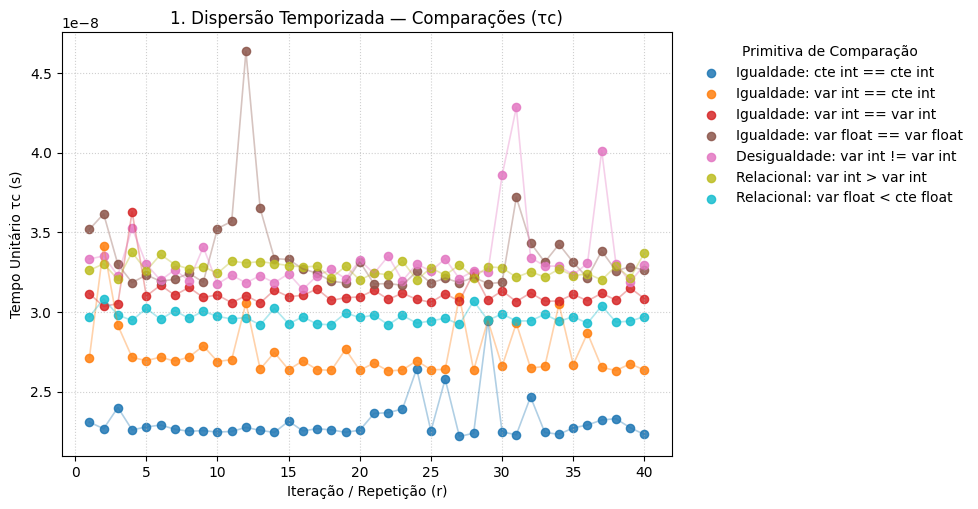

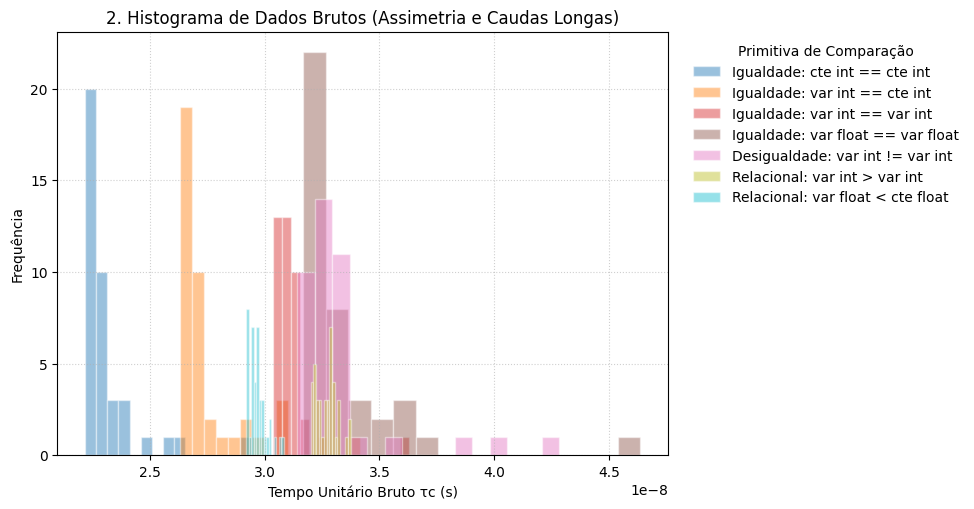

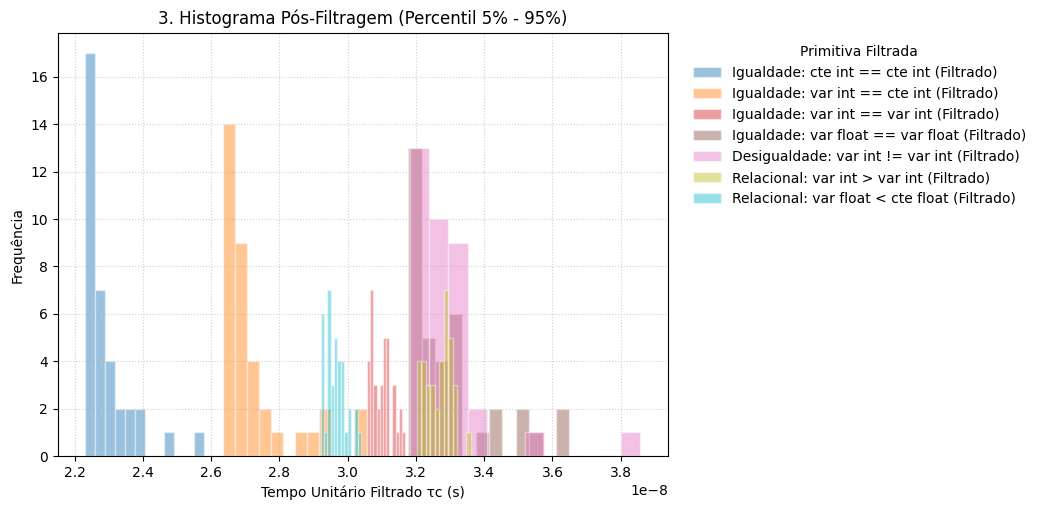

In [3]:
# ==============================================================================
# 3. PAINEL DE 3 GRÁFICOS CONSOLIDADOS (SEÇÃO 3 DO RELATÓRIO)
# ==============================================================================
# Exatamente 3 gráficos com todas as primitivas sobrepostas por cores

nomes_ops = list(tempos_brutos.keys())
cores_op = {nome: cor for nome, cor in zip(nomes_ops, plt.cm.tab10(np.linspace(0, 1, len(nomes_ops))))}

# ------------------------------------------------------------------------------
# 1) Gráfico de Dispersão Temporizada (r vs Tempo)
# Mostra todas as 7 comparações ao longo das 40 repetições, evidenciando picos
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 5.5))
for nome in nomes_ops:
    ax.scatter(reps, tempos_brutos[nome], color=cores_op[nome], label=nome, alpha=0.85, s=35)
    ax.plot(reps, tempos_brutos[nome], color=cores_op[nome], alpha=0.35, lw=1.2)

ax.set_xlabel("Iteração / Repetição (r)")
ax.set_ylabel("Tempo Unitário τc (s)")
ax.set_title("1. Dispersão Temporizada — Comparações (τc)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False, title="Primitiva de Comparação")
ax.grid(True, linestyle=":", alpha=0.6)
fig.subplots_adjust(right=0.68)
plt.show()

# ------------------------------------------------------------------------------
# 2) Histograma de Dados Brutos (Distribuição Sobreposta)
# Mostra a assimetria e caudas longas causadas por ruído sistêmico
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 5.5))
for nome in nomes_ops:
    ax.hist(tempos_brutos[nome], bins=15, alpha=0.45, color=cores_op[nome], label=nome, edgecolor="white")

ax.set_xlabel("Tempo Unitário Bruto τc (s)")
ax.set_ylabel("Frequência")
ax.set_title("2. Histograma de Dados Brutos (Assimetria e Caudas Longas)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False, title="Primitiva de Comparação")
ax.grid(True, linestyle=":", alpha=0.6)
fig.subplots_adjust(right=0.68)
plt.show()

# ------------------------------------------------------------------------------
# 3) Histograma Pós-Filtragem (Percentil 5% e 95%)
# Mostra a distribuição após filtro, com estreitamento e tendência à normalidade
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 5.5))
for nome in nomes_ops:
    ax.hist(tempos_filtrados[nome], bins=12, alpha=0.45, color=cores_op[nome], label=f"{nome} (Filtrado)", edgecolor="white")

ax.set_xlabel("Tempo Unitário Filtrado τc (s)")
ax.set_ylabel("Frequência")
ax.set_title("3. Histograma Pós-Filtragem (Percentil 5% - 95%)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False, title="Primitiva Filtrada")
ax.grid(True, linestyle=":", alpha=0.6)
fig.subplots_adjust(right=0.68)
plt.show()


In [4]:
# ==============================================================================
# 4. MATRIZ FINAL DE CALIBRAÇÃO HOMOLOGADA (τc) - TABELA 4.2
# ==============================================================================

# Configura o pandas para exibir todas as colunas sem quebra de linhas
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

df_tau_c = pd.DataFrame(tabela_resultados)

print("\n" + "="*80)
print("4.2. CUSTO DE COMPARAÇÕES (τc) - HOMOLOGAÇÃO (CV < 0.15)")
print("="*80)

# 1. Exibição garantida em texto plano (sem quebra)
print(df_tau_c.to_string(index=False))

# 2. Renderização interativa de tabela do Jupyter/VS Code
df_tau_c



4.2. CUSTO DE COMPARAÇÕES (τc) - HOMOLOGAÇÃO (CV < 0.15)
         Operação e Tipagem Exata µbruta (s) σbruta (s) CVbruto µfil(τc) (s)   σfil (s)  CVfil < 0.15
    Igualdade: cte int == cte int 2.3146e-08 1.3599e-09  0.0588   2.2931e-08 7.2682e-10 0.0317    Sim
    Igualdade: var int == cte int 2.7469e-08 1.6751e-09  0.0610   2.7250e-08 1.1730e-09 0.0430    Sim
    Igualdade: var int == var int 3.1139e-08 9.2196e-10  0.0296   3.0998e-08 3.0118e-10 0.0097    Sim
Igualdade: var float == var float 3.3368e-08 2.5593e-09  0.0767   3.2992e-08 1.3269e-09 0.0402    Sim
 Desigualdade: var int != var int 3.3254e-08 2.2658e-09  0.0681   3.2890e-08 1.2041e-09 0.0366    Sim
    Relacional: var int > var int 3.2688e-08 4.6306e-10  0.0142   3.2668e-08 3.8894e-10 0.0119    Sim
Relacional: var float < cte float 2.9677e-08 3.9350e-10  0.0133   2.9643e-08 3.0158e-10 0.0102    Sim


,Operação e Tipagem Exata,µbruta (s),σbruta (s),CVbruto,µfil(τc) (s),σfil (s),CVfil,< 0.15
0,Igualdade: cte int == cte int,2.3146e-08,1.3599e-09,0.0588,2.2931e-08,7.2682e-10,0.0317,Sim
1,Igualdade: var int == cte int,2.7469e-08,1.6751e-09,0.0610,2.7250e-08,1.1730e-09,0.0430,Sim
2,Igualdade: var int == var int,3.1139e-08,9.2196e-10,0.0296,3.0998e-08,3.0118e-10,0.0097,Sim
3,Igualdade: var float == var float,3.3368e-08,2.5593e-09,0.0767,3.2992e-08,1.3269e-09,0.0402,Sim
4,Desigualdade: var int != var int,3.3254e-08,2.2658e-09,0.0681,3.2890e-08,1.2041e-09,0.0366,Sim
5,Relacional: var int > var int,3.2688e-08,4.6306e-10,0.0142,3.2668e-08,3.8894e-10,0.0119,Sim
6,Relacional: var float < cte float,2.9677e-08,3.9350e-10,0.0133,2.9643e-08,3.0158e-10,0.0102,Sim


In [ ]:
# ==============================================================================
# 5. (OPCIONAL) PAINEL 1x3 PARA UMA PRIMITIVA ESPECÍFICA
# ==============================================================================
# Use caso queira inspecionar isoladamente alguma das 7 comparações

def plot_painel_individual(nome_op):
    raw = tempos_brutos[nome_op]
    fil = tempos_filtrados[nome_op]
    p5, p95 = cortes_percentil[nome_op]
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
    fig.suptitle(f"Painel Individual de Estabilidade — {nome_op}", fontsize=13, fontweight="bold")
    
    # 1. Dispersão Temporizada
    axes[0].scatter(reps, raw, color="#3B6BB5", s=35, alpha=0.85, edgecolor="white")
    axes[0].plot(reps, raw, color="#3B6BB5", alpha=0.35, lw=1.2)
    axes[0].set_xlabel("Iteração / Repetição (r)")
    axes[0].set_ylabel("Tempo Unitário τc (s)")
    axes[0].set_title("1. Dispersão Temporizada (Picos SO/GC)")
    axes[0].grid(True, linestyle=":", alpha=0.6)
    
    # 2. Histograma de Dados Brutos
    axes[1].hist(raw, bins=12, color="#6B6B6B", edgecolor="white", alpha=0.8)
    axes[1].set_xlabel("Tempo Bruto τc (s)")
    axes[1].set_ylabel("Frequência")
    axes[1].set_title("2. Histograma Bruto (Assimetria / Cauda Longa)")
    axes[1].grid(True, linestyle=":", alpha=0.6)
    
    # 3. Histograma Pós-Filtragem
    axes[2].hist(fil, bins=10, color="#C1553B", edgecolor="white", alpha=0.8, label="Filtrado (5%-95%)")
    axes[2].axvline(p5, color="black", ls="--", lw=1.3, label=f"Corte P5% ({p5:.2e}s)")
    axes[2].axvline(p95, color="darkred", ls=":", lw=1.3, label=f"Corte P95% ({p95:.2e}s)")
    axes[2].set_xlabel("Tempo Filtrado τc (s)")
    axes[2].set_ylabel("Frequência")
    axes[2].set_title("3. Histograma Pós-Filtragem (Normalidade)")
    axes[2].legend(frameon=False, fontsize=9)
    axes[2].grid(True, linestyle=":", alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# Exemplo de inspeção individual (descomente para usar):
# plot_painel_individual("Igualdade: var int == var int")
